# 04 - EDA

In this notebook, we will explore the dataset extracted from the Defectors project:
- Understand distributions of numeric and categorical features
- Examine label balance and repo distributions
- Explore correlations and feature importance potential
- Inspect text fields, embeddings, and code-related metrics
- Detect outliers and anomalies

## 4.1 Set Up

### 4.1.1 Logger

In [45]:
from jupyter_init import setup

setup()

from logging_config import MyLogger
from constants import LOG_DIR

logger = MyLogger(label="EDA", section_name=None, file_log_path=LOG_DIR / "EDA.log")
logger.start_session()

================== Starting notebook: None (Session 632) ==================


632

### 1.1.3 Libs

In [46]:
from src_code.config import *
from notebooks.juputils import display_func
from src_code.ml_pipeline.EDA.utils import log_general_overview
from src_code.ml_pipeline.EDA.utils import log_missing_values
from src_code.ml_pipeline.EDA.utils import log_numeric_features_with_negatives
from src_code.ml_pipeline.EDA.plots import plot_num_feature_distributions, plot_pairwise_relationship
from src_code.ml_pipeline.EDA.correlations import plot_corr_matrix
from notebooks.constants import ENGINEERED_FEATURES, TARGET
from src_code.ml_pipeline.EDA.plots import plot_commit_msg_len_distribution
from src_code.ml_pipeline.EDA.utils import log_empty_content_rows
from src_code.ml_pipeline.EDA.plots import plot_line_discrepancy_distribution
from src_code.ml_pipeline.EDA.outliers import plot_boxplots_with_outliers
from src_code.ml_pipeline.EDA.plots import plot_embedding_norm_distribution
from src_code.ml_pipeline.EDA.utils import log_negative_time_since_last_change
from src_code.ml_pipeline.EDA.plots import plot_feature_relationships_with_label
from src_code.ml_pipeline.EDA.plots import plot_keyword_distributions
from src_code.ml_pipeline.EDA.plots import plot_2D_embedding_separability
from src_code.ml_pipeline.data_utils import load_input_dfs_eda
from notebooks.constants import TARGET
from src_code.ml_pipeline.EDA.plots import plot_categorical_comparison
from src_code.ml_pipeline.EDA.utils import NumFeatureSets
from src_code.ml_pipeline.data_utils import EDAMode

### 1.1.4 Loading Datasets

In [47]:
subset_type: SubsetType = 'train'
mode: EDAMode = 'preprocessed'

dfs = load_input_dfs_eda(mode=mode, logger=logger)
df = dfs[subset_type]

[EDA RESULT] Current newest version: C:\Users\fmojt\Code\DPThesis\DP_Thesis\data\processed\transformed\train_transformed_v35.feather
[EDA CHECK] Loading the dataset from C:\Users\fmojt\Code\DPThesis\DP_Thesis\data\processed\transformed\train_transformed_v35.feather...
[EDA RESULT] Loaded dataframe with 58244 rows and 285 columns

[EDA RESULT] Current newest version: C:\Users\fmojt\Code\DPThesis\DP_Thesis\data\processed\transformed\test_transformed_v27.feather
[EDA CHECK] Loading the dataset from C:\Users\fmojt\Code\DPThesis\DP_Thesis\data\processed\transformed\test_transformed_v27.feather...
[EDA RESULT] Loaded dataframe with 2682 rows and 285 columns

[EDA RESULT] Current newest version: C:\Users\fmojt\Code\DPThesis\DP_Thesis\data\processed\transformed\val_transformed_v28.feather
[EDA CHECK] Loading the dataset from C:\Users\fmojt\Code\DPThesis\DP_Thesis\data\processed\transformed\val_transformed_v28.feather...
[EDA RESULT] Loaded dataframe with 2956 rows and 285 columns



## 4.2 EDA

In [48]:
logger.log_check("Starting the EDA process...", print_to_console=True)

[EDA CHECK] Starting the EDA process...


### 4.2.1 General Overview

In [49]:
display_func(log_general_overview)

def log_general_overview(df: pd.DataFrame, logger: MyLogger):
    # log.info("[EDA CHECK] Checking the general overview...")
    logger.log_check("Checking the general overview...", print_to_console=True)
    # print(f"Dataset shape: {df.shape}")
    # log.info(f"[EDA RESULT] Dataset shape: {df.shape}")
    logger.log_result(f"Dataset shape: {df.shape}", print_to_console=True)

    # First few rows
    df.head()

    # Column types
    # df_dtypes = df.dtypes
    # Convert dtypes to list of tuples
    dtypes_list = [(col, str(dtype)) for col, dtype in df.dtypes.items()]

    # Log it
    # log.info(f"[EDA RESULT] Dtypes: {dtypes_list}")
    logger.log_result(f"Dtypes: {dtypes_list}", print_to_console=True)

In [50]:
log_general_overview(df, logger=logger)

[EDA CHECK] Checking the general overview...
[EDA RESULT] Dataset shape: (58244, 285)
[EDA RESULT] Dtypes: [('tfidf_add', 'float64'), ('tfidf_adding', 'float64'), ('tfidf_adds', 'float64'), ('tfidf_airflow', 'float64'), ('tfidf_allow', 'float64'), ('tfidf_ansible', 'float64'), ('tfidf_api', 'float64'), ('tfidf_authored', 'float64'), ('tfidf_bug', 'float64'), ('tfidf_change', 'float64'), ('tfidf_changed', 'float64'), ('tfidf_changes', 'float64'), ('tfidf_check', 'float64'), ('tfidf_closes', 'float64'), ('tfidf_code', 'float64'), ('tfidf_command', 'float64'), ('tfidf_comments', 'float64'), ('tfidf_commit', 'float64'), ('tfidf_config', 'float64'), ('tfidf_correct', 'float64'), ('tfidf_data', 'float64'), ('tfidf_default', 'float64'), ('tfidf_device', 'float64'), ('tfidf_doc', 'float64'), ('tfidf_docs', 'float64'), ('tfidf_documentation', 'float64'), ('tfidf_don', 'float64'), ('tfidf_error', 'float64'), ('tfidf_errors', 'float64'), ('tfidf_event', 'float64'), ('tfidf_example', 'float64'), (

### 4.2.2 Missing Values

In [51]:
display_func(log_missing_values)

def log_missing_values(df: pd.DataFrame, logger: MyLogger):
    # log.info("[EDA CHECK] Checking missing values...") 
    logger.log_check("Checking missing values...", print_to_console=True)

    # Check missing values
    missing = df.isnull().sum()
    missing_nonzero = missing[missing > 0]

    # Convert to list of tuples for compact logging
    missing_list = [(col, int(count)) for col, count in missing_nonzero.items()]

    # Log
    # log.info(f"[EDA RESULT] Missing values (only non-zero): {missing_list}")
    logger.log_result(f"Missing values (only non-zero): {missing_list}", print_to_console=True)

In [52]:
log_missing_values(df, logger=logger)

[EDA CHECK] Checking missing values...
[EDA RESULT] Missing values (only non-zero): []


### 4.2.3 Label Distribution

In [53]:
display_func(plot_categorical_comparison)

def plot_categorical_comparison(
    dfs: Dict[str, pd.DataFrame],
    feature: str,
    logger: MyLogger,
    experiment_dir: Path = None,
    rows_per_page: int = 3,
):
    """Compares categorical distributions across multiple dataframes."""

    if experiment_dir:
        experiment_dir.mkdir(parents=True, exist_ok=True)

    # We use our generator to handle the layout
    gen = grid_paginator(
        [feature], feature, experiment_dir, n_cols=1, rows_per_page=rows_per_page
    )

    for ax, feature in gen:
        # Combine counts from all DFs for comparison
        plot_data = []
        for name, df in dfs.items():
            counts = df[feature].value_counts(normalize=True).reset_index()
            counts.columns = [feature, "proportion"]
            counts["Source"] = name
            plot_data.append(counts)

        comparison_df = pd.concat(plot_data)

        sns.barplot(
            data=comparison_df,
            x=feature,
            y="proportion",
            hue="Source",
            ax=ax,
            palette="muted",
        )
        ax.set_title(f"Comparison: {feature}", fontweight="bold")
        ax.set_ylabel("Proportion of Commits")
        ax.legend(title="Dataset")

    logger.log_result(f"Categorical comparison for {feature} completed.")

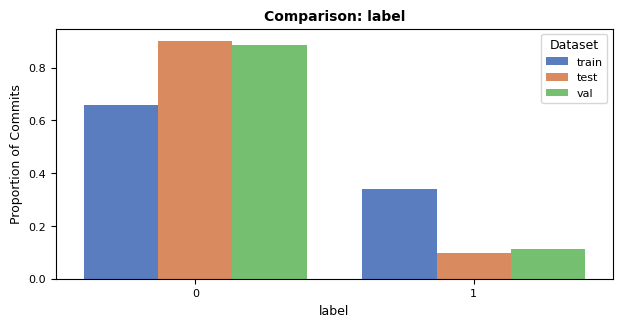

[EDA RESULT] Categorical comparison for label completed.


In [54]:
plot_categorical_comparison(dfs=dfs, feature=TARGET, logger=logger, experiment_dir=None, rows_per_page=3)

### 4.2.4 Repository Distribution

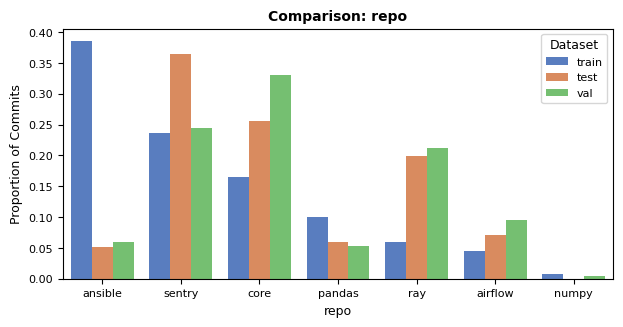

[EDA RESULT] Categorical comparison for repo completed.


In [55]:
plot_categorical_comparison(dfs=dfs, feature='repo', logger=logger, experiment_dir=None, rows_per_page=3)

### 4.2.5 Feature Overview

In [56]:
display_func(NumFeatureSets.extract_features)

@staticmethod
    def extract_features(df: pd.DataFrame, logger: MyLogger):
        logger.log_check("Checking numeric features...")
        num_cols = df.select_dtypes(include=[np.number, np.bool]).columns.tolist()
        num_cols.remove('label')  # exclude target

        embedding_cols = [c for c in num_cols if is_embedding_column(c)]
        tfidf_vectorized_cols = [c for c in num_cols if is_tfidf_vectorized(c)]
        engineered_cols = [c for c in num_cols if is_engineered(c)]

        numeric_cols = [c for c in num_cols if not is_embedding_column(c) and not is_tfidf_vectorized(c) and not is_engineered(c)]



        logger.log_result(f"Embeddings: {embedding_cols}")
        logger.log_result(f"Size: {len(embedding_cols)}")
        logger.log_result("")
        logger.log_result(f"tfidf_vectorized: {tfidf_vectorized_cols}")
        logger.log_result(f"Size: {len(tfidf_vectorized_cols)}")
        logger.log_result("")

        logger.log_result(f"Structural: {numeric_cols}")
        logger.log_result(f"Size: {len(numeric_cols)}")

        return NumFeatureSets(
            numeric_cols=numeric_cols,
            engineered_cols=engineered_cols,
            embedding_cols=embedding_cols,
            tfidf_vectorized_cols=tfidf_vectorized_cols,
        )

In [57]:
feature_ctgs = NumFeatureSets.extract_features(df, logger=logger)

[EDA CHECK] Checking numeric features...
[EDA RESULT] Embeddings: ['code_emb_0', 'code_emb_1', 'code_emb_2', 'code_emb_3', 'code_emb_4', 'code_emb_5', 'code_emb_6', 'code_emb_7', 'code_emb_8', 'code_emb_9', 'code_emb_10', 'code_emb_11', 'code_emb_12', 'code_emb_13', 'code_emb_14', 'code_emb_15', 'code_emb_16', 'code_emb_17', 'code_emb_18', 'code_emb_19', 'code_emb_20', 'code_emb_21', 'code_emb_22', 'code_emb_23', 'code_emb_24', 'code_emb_25', 'code_emb_26', 'code_emb_27', 'code_emb_28', 'code_emb_29', 'code_emb_30', 'code_emb_31', 'code_emb_32', 'code_emb_33', 'code_emb_34', 'code_emb_35', 'code_emb_36', 'code_emb_37', 'code_emb_38', 'code_emb_39', 'code_emb_40', 'code_emb_41', 'code_emb_42', 'code_emb_43', 'code_emb_44', 'code_emb_45', 'code_emb_46', 'code_emb_47', 'code_emb_48', 'code_emb_49', 'code_emb_50', 'code_emb_51', 'code_emb_52', 'code_emb_53', 'code_emb_54', 'code_emb_55', 'code_emb_56', 'code_emb_57', 'code_emb_58', 'code_emb_59', 'msg_emb_0', 'msg_emb_1', 'msg_emb_2', 'msg

#### 4.2.5.1 Negative numeric features

In [58]:
display_func(log_numeric_features_with_negatives)

def log_numeric_features_with_negatives(df: pd.DataFrame, logger: MyLogger):
    logger.log_check("Checking negative numeric features...")

    negatives = []

    for col in NUMERIC_FEATURES:
        # Calculate the total number of rows (non-NaN count) in the column
        total_count = df[col].count()

        # Calculate the number of negative values in the column
        negative_count = (df[col] < 0).sum()

        # Calculate the proportion of negative values
        if total_count > 0:
            proportion = negative_count / total_count
        else:
            proportion = 0  # Handle case where the column is entirely NaN or empty

        if proportion:
            logger.log_result(
                f"Negative Feature: **{col}** - Count of negative values: {negative_count} - Proportion of negative values: **{proportion:.4f}"
            )
            # log_result(f"Total entries (non-NaN): {total_count}")
            # log_result(f"Count of negative values: {negative_count}")
            # log_result(f"Proportion of negative values: **{proportion:.4f}**")

    # log_result(f"Found following negative features: {negatives}")

    for negative in negatives:
        print(df[negative].describe())

    logger.log_result(f"Found following negative features: {negatives}")

In [59]:
log_numeric_features_with_negatives(df, logger=logger)

[EDA CHECK] Checking negative numeric features...
[EDA RESULT] Found following negative features: []


#### 4.2.5.2 - Numeric Feature Distributions

In [60]:
display_func(plot_num_feature_distributions)

def plot_num_feature_distributions(
    df: pd.DataFrame,
    logger: MyLogger,
    feature_ctgs: NumFeatureSets,
    col_type: Literal[
        "structural", "engineered", "embedding", "vectorized"
    ] = "structural",
    experiment_dir: Path = None,
    drop_cols: Iterable[str] = None,
    preset="a4-portrait",
    rows_per_page=6,
    cols_per_page=2,
):

    def sample_cols(cols, logger: MyLogger, ratio=0.05, random_state=RANDOM_STATE):
        n_total = len(cols)
        n_sample = max(1, int(n_total * ratio))
        logger.log_result(
            f"Sampling {n_sample} out of {n_total} embedding columns for plotting."
        )

        rng = np.random.default_rng(random_state)
        return rng.choice(cols, size=n_sample, replace=False).tolist()

    logger.log_check(
        "Checking Numeric Feature Distribution Shape (NAME, SKEW, KURT, MEAN, STD)..."
    )
    # num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # num_cols.remove('label')  # exclude target

    # embedding_cols = [c for c in num_cols if is_embedding_column(c)]
    # other_numeric_cols = [c for c in num_cols if not is_embedding_column(c)]

    summary = []
    # filtered_cols = [
    #     feature
    #     for feature in feature_ctgs.structural_cols
    #     if feature not in ENGINEERED_FEATURES
    # ]
    # filtered_cols = cols if cols else feature_ctgs.structural_cols

    match col_type:
        case "structural":
            filtered_cols = [
                feature
                for feature in feature_ctgs.numeric_cols
                if feature not in ENGINEERED_FEATURES
            ]
        case "engineered":
            # filtered_cols = [
            #     feature
            #     for feature in feature_ctgs.numeric_cols
            #     if feature in ENGINEERED_FEATURES
            # ]
            filtered_cols = feature_ctgs.engineered_cols
        case "embedding":
            # filtered_cols = feature_ctgs.embedding_cols
            filtered_cols = sample_cols(
                feature_ctgs.embedding_cols, ratio=0.20, logger=logger
            )
        case "vectorized":
            # filtered_cols = feature_ctgs.tfidf_vectorized_cols
            filtered_cols = sample_cols(
                feature_ctgs.tfidf_vectorized_cols, ratio=0.20, logger=logger
            )

        case _:
            filtered_cols = feature_ctgs.numeric_cols

    if drop_cols:
        filtered_cols = [col for col in filtered_cols if col not in drop_cols]

    for col in filtered_cols:
        data = df[col].dropna()
        if data.empty:
            continue

        # skew = round(stats.skew(df[col].dropna()), 3)
        # kurt = round(stats.kurtosis(df[col].dropna()), 3)
        # mean = round(df[col].mean(), 3)
        # std = round(df[col].std(), 3)
        # 1. Existing Stats
        skew = round(stats.skew(data), 3)
        kurt = round(stats.kurtosis(data), 3)
        mean = data.mean()
        std = data.std()

        # summary.append((col, skew, kurt, mean, std))
        # 2. New Stability & Sparsity Metrics
        variance = round(data.var(), 3)

        # Coefficient of Variation (CV = Std / Mean)
        # Use a conditional to avoid division by zero
        cv = round(std / mean, 3) if mean != 0 else np.nan

        # Sparsity: Percentage of values that are exactly 0
        pct_zeros = round((data == 0).sum() / len(data) * 100, 2)

        summary.append(
            (col, skew, kurt, round(mean, 3), round(std, 3), variance, cv, pct_zeros)
        )

    # Log as single line
    logger.log_result(
        f"Numeric distributions summary (col_name, skew, kurt, mean, std): {summary}"
    )

    stats_df = pd.DataFrame(
        summary,
        columns=[
            "Feature",
            "Skew",
            "Kurt",
            "Mean",
            "Std",
            "Var",
            "CV",
            "Pct_Zeros",
        ],
    )

    if experiment_dir:
        experiment_dir.mkdir(parents=True, exist_ok=True)
       

[EDA CHECK] Checking Numeric Feature Distribution Shape (NAME, SKEW, KURT, MEAN, STD)...
[EDA RESULT] Numeric distributions summary (col_name, skew, kurt, mean, std): [('author_exp_pre', np.float64(-0.324), np.float64(-1.254), np.float64(3.85), np.float64(2.41), np.float64(5.81), np.float64(0.626), np.float64(15.1)), ('author_recent_activity_pre', np.float64(-0.064), np.float64(-1.391), np.float64(2.207), np.float64(1.629), np.float64(2.653), np.float64(0.738), np.float64(23.59)), ('loc_added', np.float64(0.244), np.float64(-1.222), np.float64(1.836), np.float64(1.285), np.float64(1.651), np.float64(0.7), np.float64(12.77)), ('loc_deleted', np.float64(-0.008), np.float64(-1.229), np.float64(2.548), np.float64(1.451), np.float64(2.107), np.float64(0.57), np.float64(5.0)), ('files_changed', np.float64(0.349), np.float64(-0.753), np.float64(1.093), np.float64(0.5), np.float64(0.25), np.float64(0.458), np.float64(2.94)), ('hunks_count', np.float64(0.09), np.float64(-0.829), np.float64(2.09

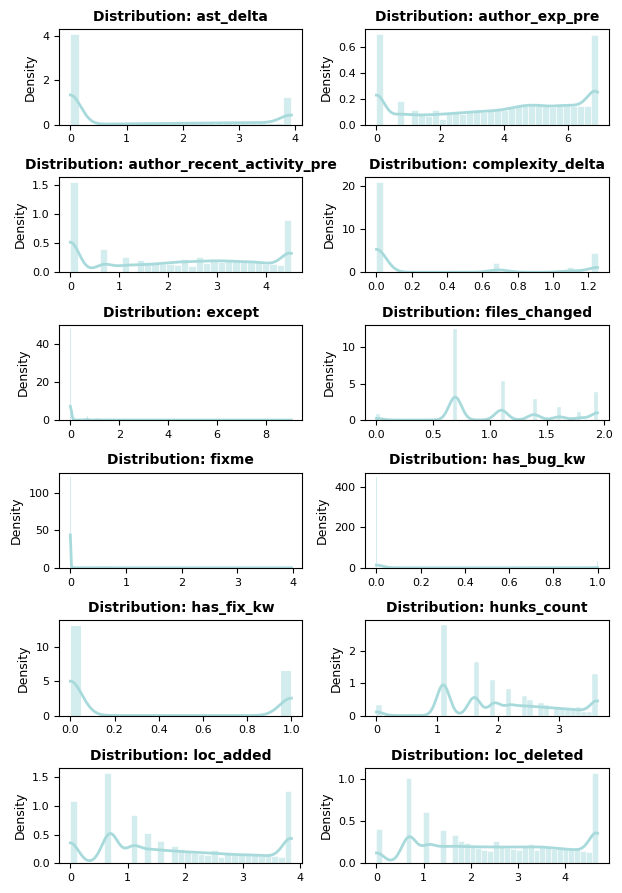

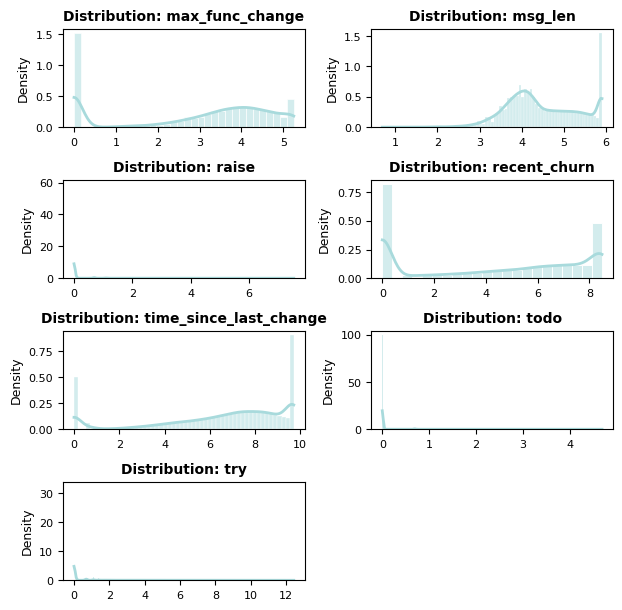

In [61]:
stat_df = plot_num_feature_distributions(df, logger=logger, feature_ctgs=feature_ctgs, col_type='structural')

### 4.2.6 Embedding Distributions

[EDA CHECK] Checking Numeric Feature Distribution Shape (NAME, SKEW, KURT, MEAN, STD)...
[EDA RESULT] Sampling 28 out of 140 embedding columns for plotting.
[EDA RESULT] Numeric distributions summary (col_name, skew, kurt, mean, std): [('msg_emb_50', np.float64(0.055), np.float64(0.598), np.float64(-0.0), np.float64(0.174), np.float64(0.03), np.float64(-1513348329696877.2), np.float64(0.0)), ('msg_emb_58', np.float64(-0.028), np.float64(0.739), np.float64(-0.0), np.float64(0.162), np.float64(0.026), np.float64(-413710783990799.56), np.float64(0.0)), ('code_emb_50', np.float64(0.148), np.float64(2.235), np.float64(0.0), np.float64(0.092), np.float64(0.008), np.float64(263672229464976.7), np.float64(0.0)), ('msg_emb_72', np.float64(0.03), np.float64(0.51), np.float64(0.0), np.float64(0.142), np.float64(0.02), np.float64(462691938270538.75), np.float64(0.0)), ('msg_emb_66', np.float64(-0.022), np.float64(0.699), np.float64(-0.0), np.float64(0.149), np.float64(0.022), np.float64(-131672376

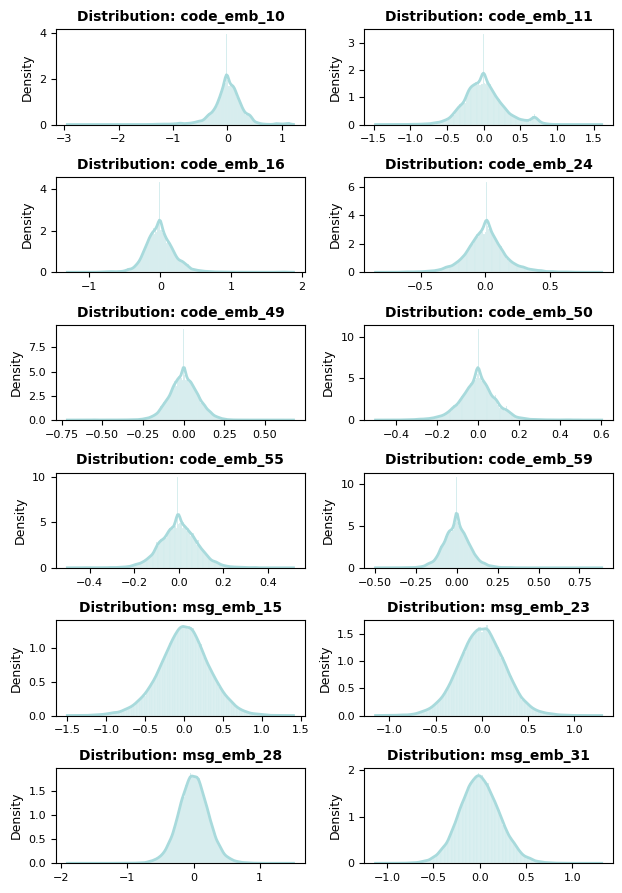

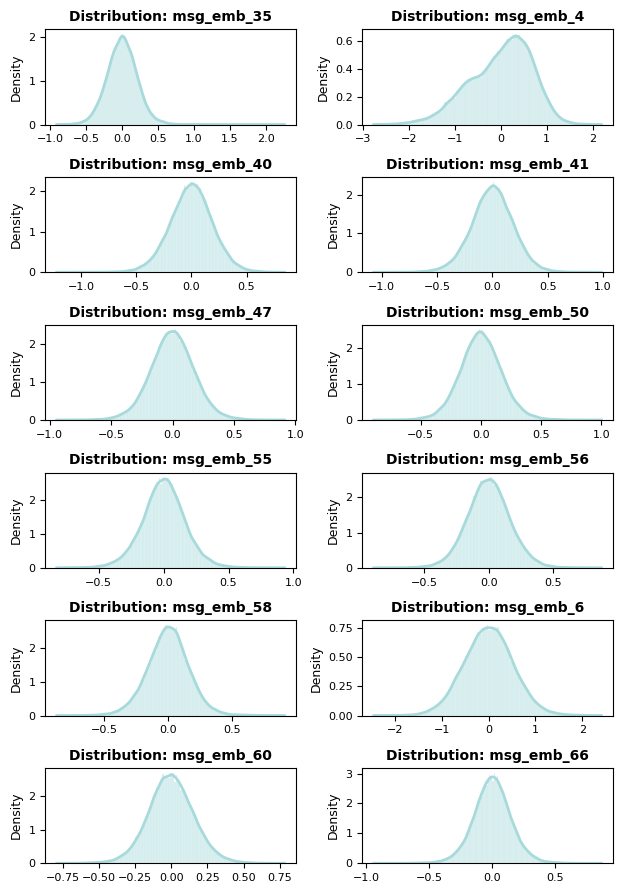

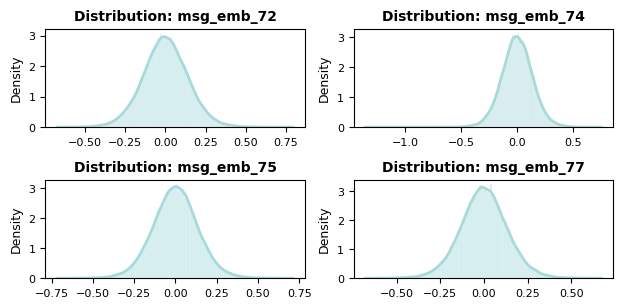

In [62]:
if mode == 'preprocessed':
    stat_df = plot_num_feature_distributions(df, logger=logger, feature_ctgs=feature_ctgs, col_type='embedding')
else:
    logger.log_result("Not plotting embedding distributions since transformed data is not being used.")

### 4.2.7 Correlations
Examine correlations between numeric features and label

In [ ]:
display_func(plot_corr_matrix)

def plot_corr_matrix(
    corr_matrix: pd.DataFrame,
    label: str,
    logger: MyLogger,
    target: str = TARGET,
    top_n: int = 15,  # Keep this manageable for a single page
    min_abs_corr: float | None = None,
    experiment_dir: Path = None
):
    logger.log_check("Computing correlation matrix...")

    # 1. Feature Selection
    if top_n:
        top_features, _ = select_top_correlated_features(
            corr=corr_matrix, target=target, top_n=top_n, min_abs_corr=min_abs_corr
        )
        selected_cols = top_features + [target]
        corr_matrix = corr_matrix.loc[selected_cols, selected_cols]

    # 2. Apply LaTeX Style BEFORE creating the figure
    setup_latex_style("a4-portrait")
    
    # 3. Calculate dynamic height based on number of features
    # A4 width is ~6.3. We want square cells, so height approx = width
    fig_width = 6.3 
    fig_height = min(fig_width * (len(selected_cols) / 10), 9.0) # Scale height but cap at page limit
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # 4. Professional Heatmap Styling
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r", # Red-Blue is more standard for academic papers
        center=0,
        square=True,
        cbar_kws={"shrink": 0.8}, # Make colorbar slightly smaller
        annot_kws={"size": 7},    # Smaller font for numbers to prevent overlap
        ax=ax
    )
    
    ax.set_title(f"Correlation Matrix: {label}", pad=20)
    
    # 5. Save with tight bounding box
    if experiment_dir:
        save_path = experiment_dir / f"{label}_heatmap.pdf"
        experiment_dir.mkdir(parents=True, exist_ok=True)
        # Use bbox_inches="tight" to ensure no labels are cut off
        plt.savefig(save_path, format='pdf', bbox_inches="tight")
        logger.log_result(f"Saved thesis-ready heatmap to {save_path}")
    else:
        plt.show()

[EDA CHECK] Computing correlation matrix...


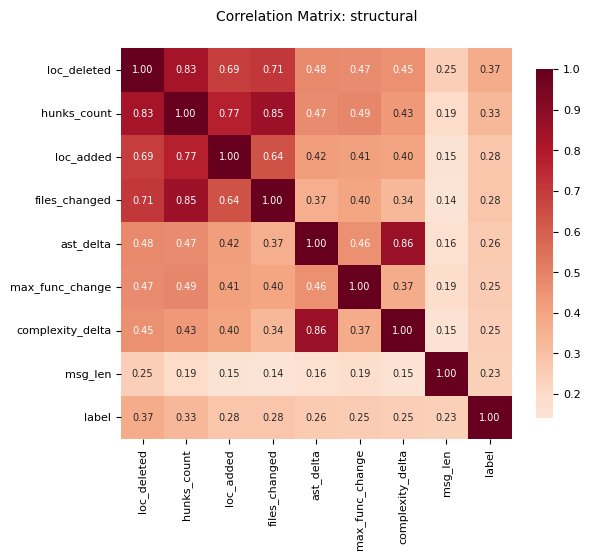

In [ ]:
corr_config = {
    "structural": {"data": feature_ctgs.numeric_cols, "top_n": 10},
    "embeddings": {"data": feature_ctgs.embedding_cols, "top_n": 30},
    "tfidf": {"data": feature_ctgs.tfidf_vectorized_cols, "top_n": 35},
}

corr_data = "structural"
corr_matrix = df[[x for x in corr_config[corr_data]["data"] if x not in ENGINEERED_FEATURES] + [TARGET]].corr()


plot_corr_matrix(
    corr_matrix=corr_matrix, logger=logger, top_n=corr_config[corr_data]["top_n"], min_abs_corr=0.2, label="structural"
)

### 4.2.8 File Types

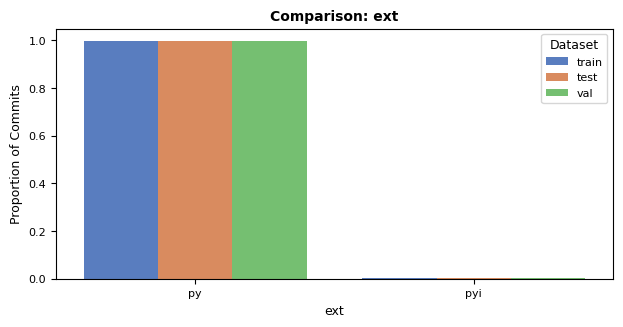

[EDA RESULT] Categorical comparison for ext completed.


In [ ]:
for df in dfs.values():
    df["ext"] = df["filepath"].str.split(".").str[-1]


plot_categorical_comparison(
    dfs=dfs, feature="ext", logger=logger, experiment_dir=None, rows_per_page=3
)

### 4.2.9 Commit Message and Code Text Analysis

#### 4.2.9.1 Commits

In [68]:
display_func(plot_commit_msg_len_distribution)
display_func(log_empty_content_rows)

def plot_commit_msg_len_distribution(df: pd.DataFrame, logger: MyLogger):
    logger.log_check("Checking Commit Message Length Distribution...")

    # --- Commit message lengths ---
    msg_stats = df["msg_len"].describe().to_dict()
    logger.log_result(f"msg_len stats: {msg_stats}")
    plt.figure(figsize=(8, 4))
    sns.histplot(df["msg_len"], bins=50)
    plt.title("Commit Message Length Distribution")
    plt.show()

    # # --- Empty content rows ---
    # empty_content = int((df['content'].str.len() == 0).sum())
    # logger.log_result(f"Empty content rows: {empty_content}")

def log_empty_content_rows(df: pd.DataFrame, logger: MyLogger):
    # --- Empty content rows ---
    empty_content = int((df['content'].str.len() == 0).sum())
    logger.log_result(f"Empty content rows: {empty_content}")

[EDA CHECK] Checking Commit Message Length Distribution...
[EDA RESULT] msg_len stats: {'count': 2956.0, 'mean': 4.613222524582641, 'std': 0.754932523475109, 'min': 2.6390573296152584, '25%': 4.007333185232471, '50%': 4.406719247264253, '75%': 5.209486152841421, 'max': 5.901266279189834}


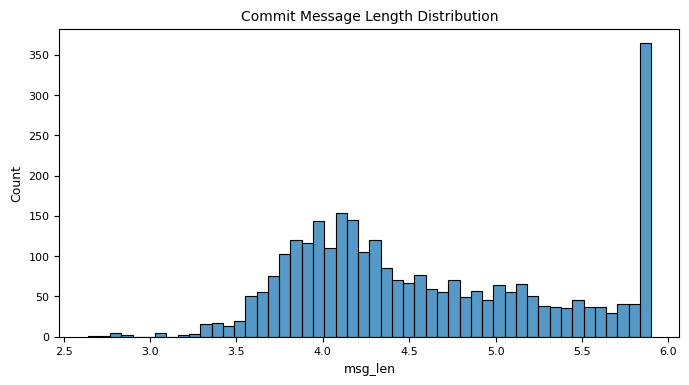

[EDA RESULT] Empty content rows: 12


In [69]:
plot_commit_msg_len_distribution(df=df, logger=logger)
log_empty_content_rows(df=df, logger=logger)

#### 4.2.9.2 Code Text

In [70]:
display_func(plot_line_discrepancy_distribution)

def plot_line_discrepancy_distribution(
    df: pd.DataFrame, logger: MyLogger, experiment_dir: Path = None
):
    logger.log_check("Plotting symlog-scaled line discrepancy distribution...")

    # --- Work on a copy to avoid side effects ---
    df = df.copy()

    # --- Extract added/deleted lines from diff ---
    df["added_from_diff"] = df["content"].str.count(
        r"^\+(?!\+\+)", flags=re.MULTILINE
    )
    df["deleted_from_diff"] = df["content"].str.count(
        r"^\-(?!--)", flags=re.MULTILINE
    )

    # --- Compute discrepancies ---
    df["added_error"] = df["added_from_diff"] - df["loc_added"]
    df["deleted_error"] = df["deleted_from_diff"] - df["loc_deleted"]

    # total discrepancy (can be negative or positive)
    line_discrepancy = df["added_error"] + df["deleted_error"]

    # --- Logging basic stats ---
    logger.log_result(
        f"Discrepancy stats | mean: {line_discrepancy.mean():.2f}, "
        f"median: {line_discrepancy.median():.2f}, "
        f"std: {line_discrepancy.std():.2f}"
    )

    zero_ratio = (line_discrepancy == 0).mean() * 100
    logger.log_result(f"Exact match (0 discrepancy): {zero_ratio:.2f}%")

    # --- Plot ---
    setup_latex_style("a4-portrait")
    fig, ax = plt.subplots(figsize=(6.3, 4))

    sns.histplot(line_discrepancy, bins=100, kde=True, ax=ax)

    # symlog handles both positive and negative values
    ax.set_xscale("symlog")

    ax.set_title("Line Discrepancy Distribution (Symlog Scale)")
    ax.set_xlabel("Discrepancy (Diff-derived - Dataset)")
    ax.set_ylabel("Count")

    ax.axvline(0, linestyle="--", alpha=0.7, label="Perfect match")
    ax.legend()

    # --- Save or show ---
    if experiment_dir:
        experiment_dir.mkdir(parents=True, exist_ok=True)
        output_path = experiment_dir / "discrepancy_symlog.pdf"
        plt.savefig(output_path, bbox_inches="tight")
        logger.log_result(f"Line discrepancy distribution saved to {output_path}")
    else:
        plt.show()


    commit_size = df["loc_added"] + df["loc_deleted"]
    df["relative_error"] = line_discrepancy / (commit_size + 1e-6)
    plt.figure(figsize=(6, 4))
    plt.scatter(commit_size, abs(line_discrepancy), alpha=0.3)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Commit Size (loc_added + loc_deleted)")
    plt.ylabel("Absolute Discrepancy")
    plt.title("Discrepancy vs Commit Size")
    plt.show()

[EDA CHECK] Plotting symlog-scaled line discrepancy distribution...
[EDA RESULT] Discrepancy stats | mean: 17.61, median: 3.56, std: 46.06
[EDA RESULT] Exact match (0 discrepancy): 0.07%


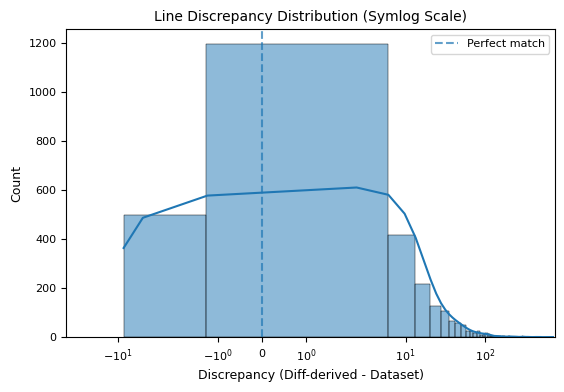

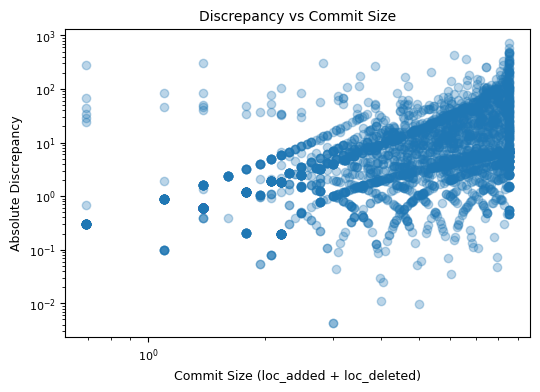

In [71]:
plot_line_discrepancy_distribution(df=df, logger=logger)

Very short messages may need normalization.

### 4.2.10 Outliers


In [72]:
display_func(plot_boxplots_with_outliers)

def plot_boxplots_with_outliers(
    df: pd.DataFrame, 
    feature_sets: NumFeatureSets, 
    logger: MyLogger, 
    experiment_dir: Path = None,
    drop_binaries: bool = True,
    n_rows_per_page: int = 3,
    n_cols_per_page: int = 2,
):
    logger.log_check("Boxplot outlier analysis with paginated output...")
    features = feature_sets.numeric_cols + feature_sets.engineered_cols

 
    if drop_binaries:
        logger.log_check("Dropping binaries...")

        binaries = [f for f in features if is_binary(df=df, col_name=f)]

        if binaries:
            df = df.drop(columns=binaries)
            features = [f for f in features if f not in binaries]

            for f in binaries:
                logger.log_result(f"Dropped binary column: {f}")
        

    # 1. Initialize the paginator
    # n_cols=1 and rows_per_page=5 fits 5 stacked boxplots on an A4 page nicely
    gen = grid_paginator(
        features=features,
        col_name='structural_boxplots', 
        experiment_dir=experiment_dir, 
        n_cols=n_cols_per_page, 
        rows_per_page=n_rows_per_page, 
        preset='a4-portrait',
        
    )

    # 2. Iterate directly over the generator
    for ax, feature in gen:
        series = df[feature].dropna()

        # Calculation Logic
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outlier_mask = (series < lower) | (series > upper)
        outlier_ratio = float(outlier_mask.mean())
        
        # Log results
        logger.log_result(
            f"{feature}: outliers={outlier_ratio:.2%}, "
            f"bounds=({lower:.2f}, {upper:.2f}), mean={series.mean():.2f}"
        )

        # 3. Plot onto the specific 'ax' provided by the paginator
        sns.boxplot(x=series, ax=ax, linewidth=1, fliersize=3)
        ax.set_title(f"{feature} (Outliers: {outlier_ratio:.2%})")
        ax.set_xlabel("") # Clean up labels for a grid look

    # Note: plt.show() or plt.savefig() is handled inside grid_paginator's loop

In [73]:
feature_ctgs.numeric_cols

['author_exp_pre',
 'author_recent_activity_pre',
 'loc_added',
 'loc_deleted',
 'files_changed',
 'hunks_count',
 'msg_len',
 'ast_delta',
 'complexity_delta',
 'max_func_change',
 'time_since_last_change',
 'recent_churn',
 'todo',
 'fixme',
 'try',
 'except',
 'raise',
 'has_fix_kw',
 'has_bug_kw']

[EDA CHECK] Boxplot outlier analysis with paginated output...
[EDA CHECK] Dropping binaries...
[EDA RESULT] Dropped binary column: has_fix_kw
[EDA RESULT] Dropped binary column: has_bug_kw
[EDA RESULT] Dropped binary column: loc_added_bucket_very_small
[EDA RESULT] Dropped binary column: loc_added_bucket_small
[EDA RESULT] Dropped binary column: loc_added_bucket_medium
[EDA RESULT] Dropped binary column: loc_added_bucket_large
[EDA RESULT] Dropped binary column: loc_added_bucket_very_large
[EDA RESULT] Dropped binary column: author_exp_pre_bucket_junior
[EDA RESULT] Dropped binary column: author_exp_pre_bucket_mid
[EDA RESULT] Dropped binary column: author_exp_pre_bucket_senior
[EDA RESULT] activity_per_exp: outliers=0.00%, bounds=(-0.75, 1.25), mean=0.26
[EDA RESULT] ast_delta: outliers=0.00%, bounds=(-5.90, 9.83), mean=1.73
[EDA RESULT] author_exp_pre: outliers=0.00%, bounds=(-3.24, 8.32), mean=2.57
[EDA RESULT] author_recent_activity_pre: outliers=0.00%, bounds=(-4.57, 7.61), mean=1

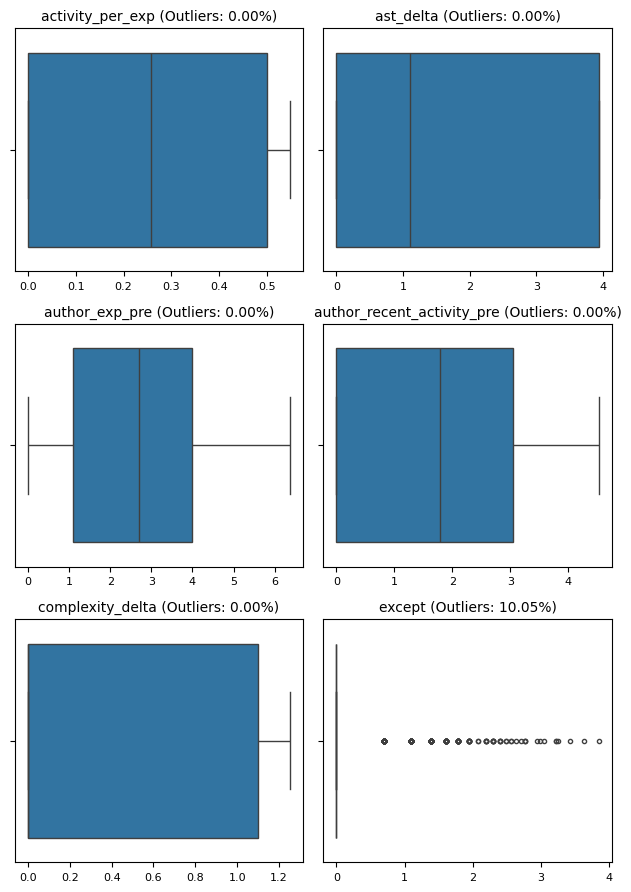

[EDA RESULT] files_changed: outliers=0.00%, bounds=(-0.95, 3.44), mean=1.26
[EDA RESULT] fixme: outliers=0.24%, bounds=(0.00, 0.00), mean=0.00
[EDA RESULT] hunks_count: outliers=0.00%, bounds=(-0.68, 5.42), mean=2.37
[EDA RESULT] line_token_total: outliers=0.00%, bounds=(-1.04, 1.73), mean=0.34
[EDA RESULT] loc_added: outliers=0.00%, bounds=(-2.25, 6.68), mean=2.10
[EDA RESULT] loc_added_x_hunks_count: outliers=0.00%, bounds=(-4.04, 12.60), mean=3.93


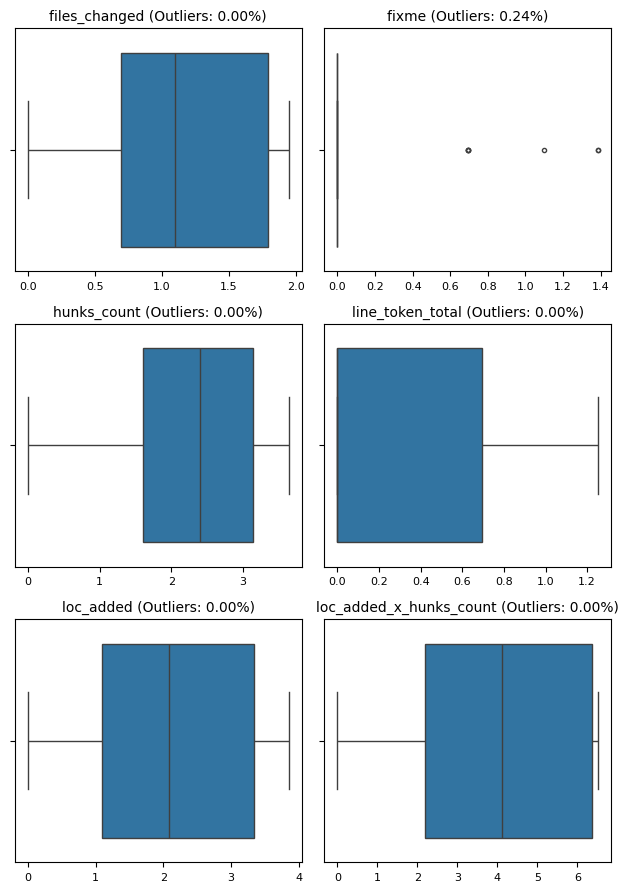

[EDA RESULT] loc_added_x_loc_deleted: outliers=0.00%, bounds=(-5.58, 14.84), mean=4.38
[EDA RESULT] loc_churn_ratio: outliers=0.00%, bounds=(-0.62, 1.34), mean=0.40
[EDA RESULT] loc_deleted: outliers=0.00%, bounds=(-1.78, 7.75), mean=2.91
[EDA RESULT] loc_deleted_x_hunks_count: outliers=0.00%, bounds=(-3.09, 13.26), mean=4.91
[EDA RESULT] max_func_change: outliers=13.40%, bounds=(0.58, 6.89), mean=3.42
[EDA RESULT] msg_len: outliers=0.00%, bounds=(2.20, 7.01), mean=4.61


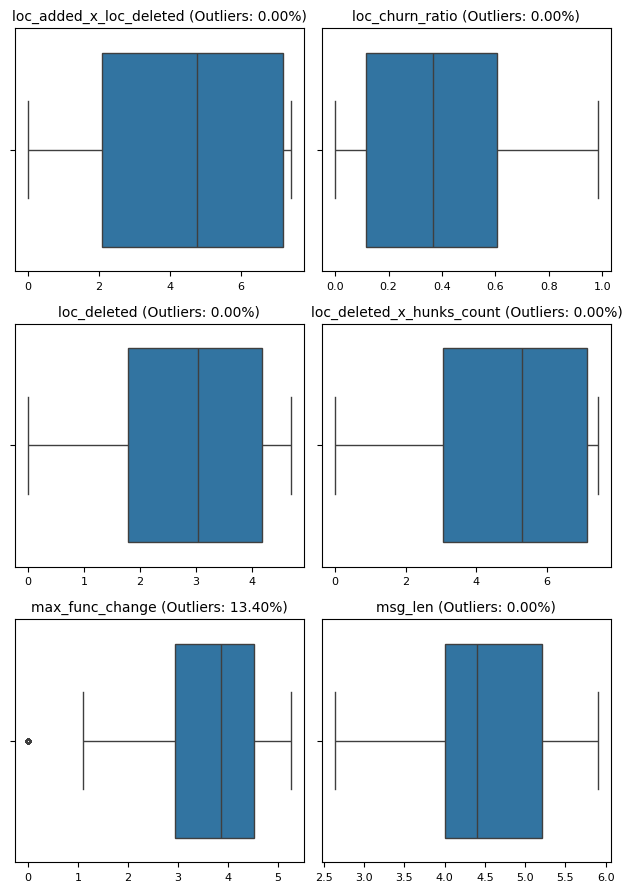

[EDA RESULT] raise: outliers=10.32%, bounds=(0.00, 0.00), mean=0.12
[EDA RESULT] recent_churn: outliers=0.00%, bounds=(-10.85, 18.09), mean=4.09
[EDA RESULT] time_since_last_change: outliers=1.18%, bounds=(0.62, 13.09), mean=6.68
[EDA RESULT] todo: outliers=5.78%, bounds=(0.00, 0.00), mean=0.05
[EDA RESULT] try: outliers=22.87%, bounds=(0.00, 0.00), mean=0.35


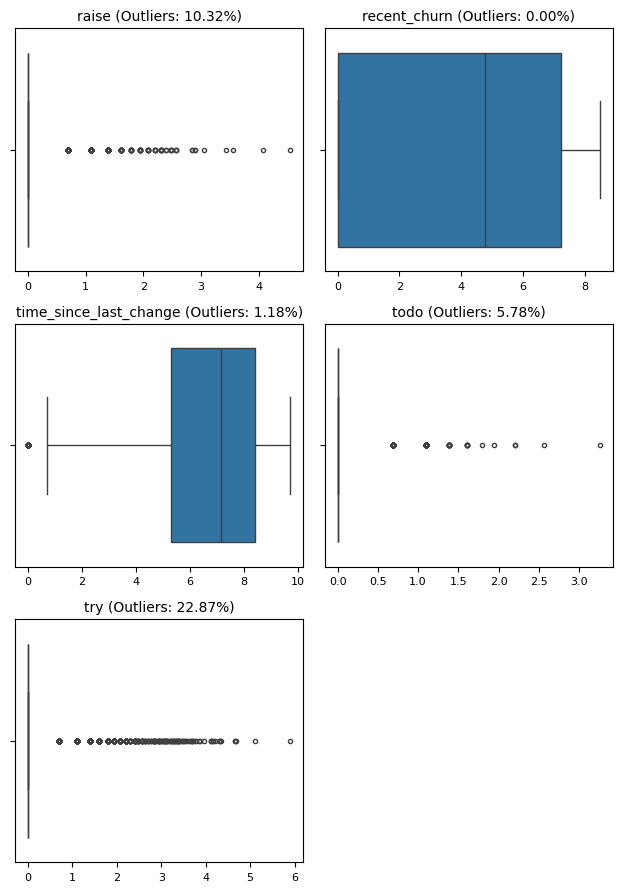

In [74]:
plot_boxplots_with_outliers(df, feature_ctgs, logger=logger)

### 4.2.11 Code and Message Embeddings

Quick check of embedding norms and distribution

In [ ]:
display_func(plot_embedding_norm_distribution)

def plot_embedding_norm_distribution(
    df: pd.DataFrame, logger: MyLogger, experiment_dir: Path = None
):
    logger.log_check(
        "Checking Embedding Norm Distributions (NAME, SKEW, KURT, MEAN, STD)..."
    )

    df["code_embed_norm"] = df["code_embed"].apply(lambda x: np.linalg.norm(x))
    df["msg_embed_norm"] = df["msg_embed"].apply(lambda x: np.linalg.norm(x))

    plt.figure(figsize=(12, 5))
    sns.histplot(df["code_embed_norm"], bins=50, kde=True)
    plt.title("Code Embedding Norm Distribution")
    # plt.show()

    if experiment_dir:
        experiment_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(
            experiment_dir / "code_embed_norm_distribution.pdf", bbox_inches="tight"
        )
    else:
        plt.show()

    plt.figure(figsize=(12, 5))
    sns.histplot(df["msg_embed_norm"], bins=50, kde=True)
    plt.title("Message Embedding Norm Distribution")

    setup_latex_style("a4-portrait")
    # plt.show()
    if experiment_dir:
        experiment_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(
            experiment_dir / "msg_embed_norm_distribution.pdf", bbox_inches="tight"
        )
    else:
        plt.show()

    for col in ["code_embed_norm", "msg_embed_norm"]:
        series = df[col].dropna()
        series_skew = skew(series)
        series_kurt = kurtosis(series)
        series_mean = series.mean()
        series_std = series.std()

    logger.log_result(
        f"{col}: skew={series_skew:.3f}, kurt={series_kurt:.3f}, mean={series_mean:.3f}, std={series_std:.3f}"
    )

[EDA CHECK] Checking Embedding Norm Distributions (NAME, SKEW, KURT, MEAN, STD)...


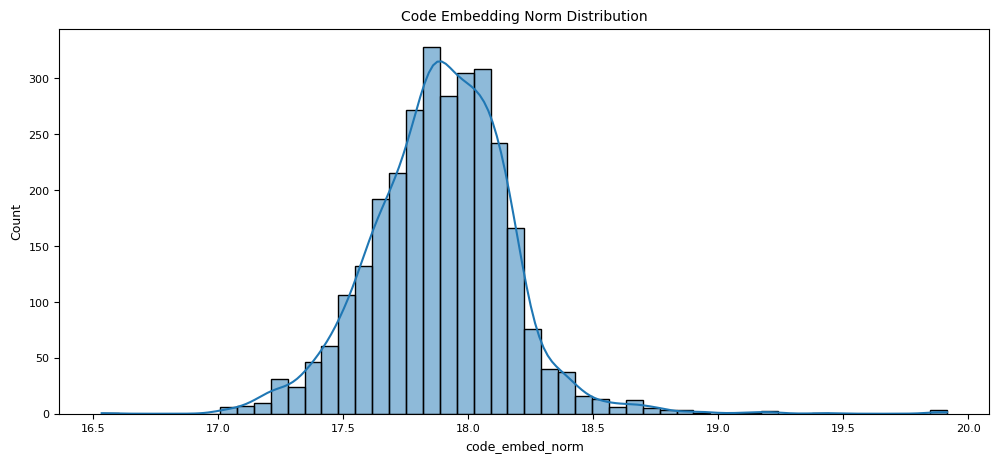

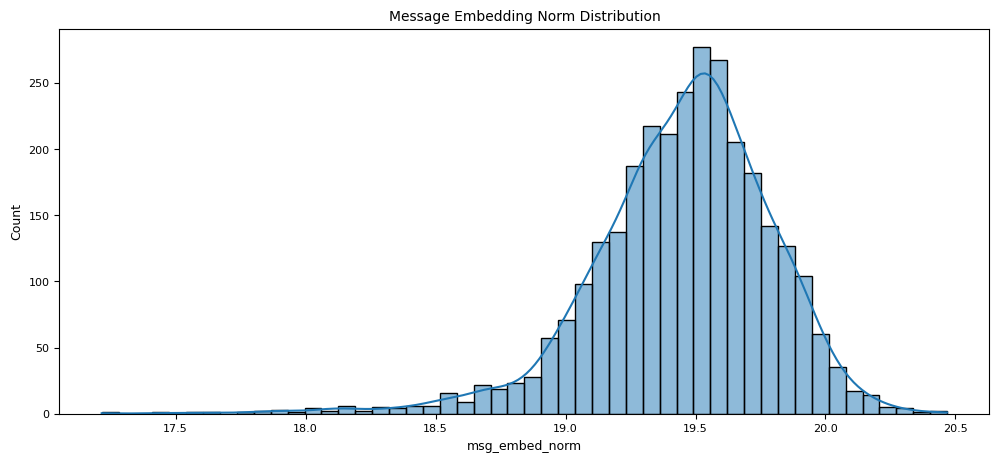

[EDA RESULT] msg_embed_norm: skew=-1.008, kurt=3.029, mean=19.449, std=0.347


In [76]:
plot_embedding_norm_distribution(df=df, logger=logger)


### 4.2.12 Anomaly Detection

#### 4.2.12.1 Negative `time_since_last_change` by Repo

In [77]:
display_func(log_negative_time_since_last_change)

def log_negative_time_since_last_change(df: pd.DataFrame, logger: MyLogger):
    logger.log_check("Checking Negative time_since_last_change per Repository...")

    # neg_times = df[df['time_since_last_change'] < 0]
    # neg_times['repo'].value_counts()
    neg_times = df[df['time_since_last_change'] < 0]
    neg_repo_counts = neg_times['repo'].value_counts()
    neg_repo_props = neg_repo_counts / len(df)

    for repo in neg_repo_counts.index:
        count = neg_repo_counts[repo]
        prop = neg_repo_props[repo]
        logger.log_result(f"{repo}: count={count}, proportion={prop:.3%}")
    sns.countplot(x='repo', data=neg_times)
    plt.title("Negative time_since_last_change by Repository")
    plt.show()

### 4.2.13 Feature Relationships with Label

Boxplots of numeric features by label

In [79]:
display_func(plot_feature_relationships_with_label)

def plot_feature_relationships_with_label(
    df: pd.DataFrame,
    cols: Iterable[str],
    logger: MyLogger,
):
    logger.log_check(
        "Checking feature distributions by label: median, IQR, min, max, outlier_ratio"
    )

    valid_cols = []

    for feature in cols:
        if feature not in df.columns:
            logger.log_result(f"Skipping missing feature: {feature}")
            continue

        # Skip non-numeric columns
        if not pd.api.types.is_numeric_dtype(df[feature]):
            logger.log_result(f"Skipping non-numeric feature: {feature}")
            continue

        # Convert boolean columns to int, or skip them if preferred
        if pd.api.types.is_bool_dtype(df[feature]):
            logger.log_result(f"Converting boolean feature to int: {feature}")
            df[feature] = df[feature].astype(int)

        valid_cols.append(feature)

        for lbl in sorted(df["label"].dropna().unique()):
            series = pd.to_numeric(
                df.loc[df["label"] == lbl, feature],
                errors="coerce",
            ).dropna()

            if series.empty:
                logger.log_result(f"{feature} | label={lbl} | empty series")
                continue

            Q1 = series.quantile(0.25)
            Q3 = series.quantile(0.75)
            IQR = Q3 - Q1
            median = series.median()
            min_val = series.min()
            max_val = series.max()

            if IQR == 0:
                outlier_ratio = 0.0
            else:
                outlier_ratio = (
                    (series < Q1 - 1.5 * IQR) |
                    (series > Q3 + 1.5 * IQR)
                ).mean()

            logger.log_result(
                f"{feature} | label={lbl} | "
                f"median={median:.2f}, IQR={IQR:.2f}, "
                f"min={min_val:.2f}, max={max_val:.2f}, "
                f"outlier_ratio={outlier_ratio:.2%}"
            )

    if not valid_cols:
        logger.log_result("No valid numeric columns to plot.")
        return

    n_features = len(valid_cols)
    n_cols = 3
    n_rows = math.ceil(n_features / n_cols)

    plt.figure(figsize=(20, 4 * n_rows))

    for i, col in enumerate(valid_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.boxplot(x="label", y=col, data=df)
        plt.title(f"{col} by label")

    plt.tight_layout()
    plt.show()

[EDA CHECK] Checking feature distributions by label: median, IQR, min, max, outlier_ratio
[EDA RESULT] author_exp_pre | label=0 | median=2.64, IQR=2.89, min=0.00, max=6.28, outlier_ratio=0.00%
[EDA RESULT] author_exp_pre | label=1 | median=2.77, IQR=2.36, min=0.00, max=6.38, outlier_ratio=0.00%
[EDA RESULT] author_recent_activity_pre | label=0 | median=1.79, IQR=3.09, min=0.00, max=4.52, outlier_ratio=0.00%
[EDA RESULT] author_recent_activity_pre | label=1 | median=0.69, IQR=2.48, min=0.00, max=4.32, outlier_ratio=0.00%
[EDA RESULT] loc_added | label=0 | median=1.95, IQR=2.08, min=0.00, max=3.85, outlier_ratio=0.00%
[EDA RESULT] loc_added | label=1 | median=3.20, IQR=1.90, min=0.00, max=3.85, outlier_ratio=0.00%
[EDA RESULT] loc_deleted | label=0 | median=2.89, IQR=2.42, min=0.00, max=4.69, outlier_ratio=0.00%
[EDA RESULT] loc_deleted | label=1 | median=4.13, IQR=1.47, min=0.00, max=4.69, outlier_ratio=1.50%
[EDA RESULT] files_changed | label=0 | median=1.10, IQR=0.92, min=0.00, max=1.

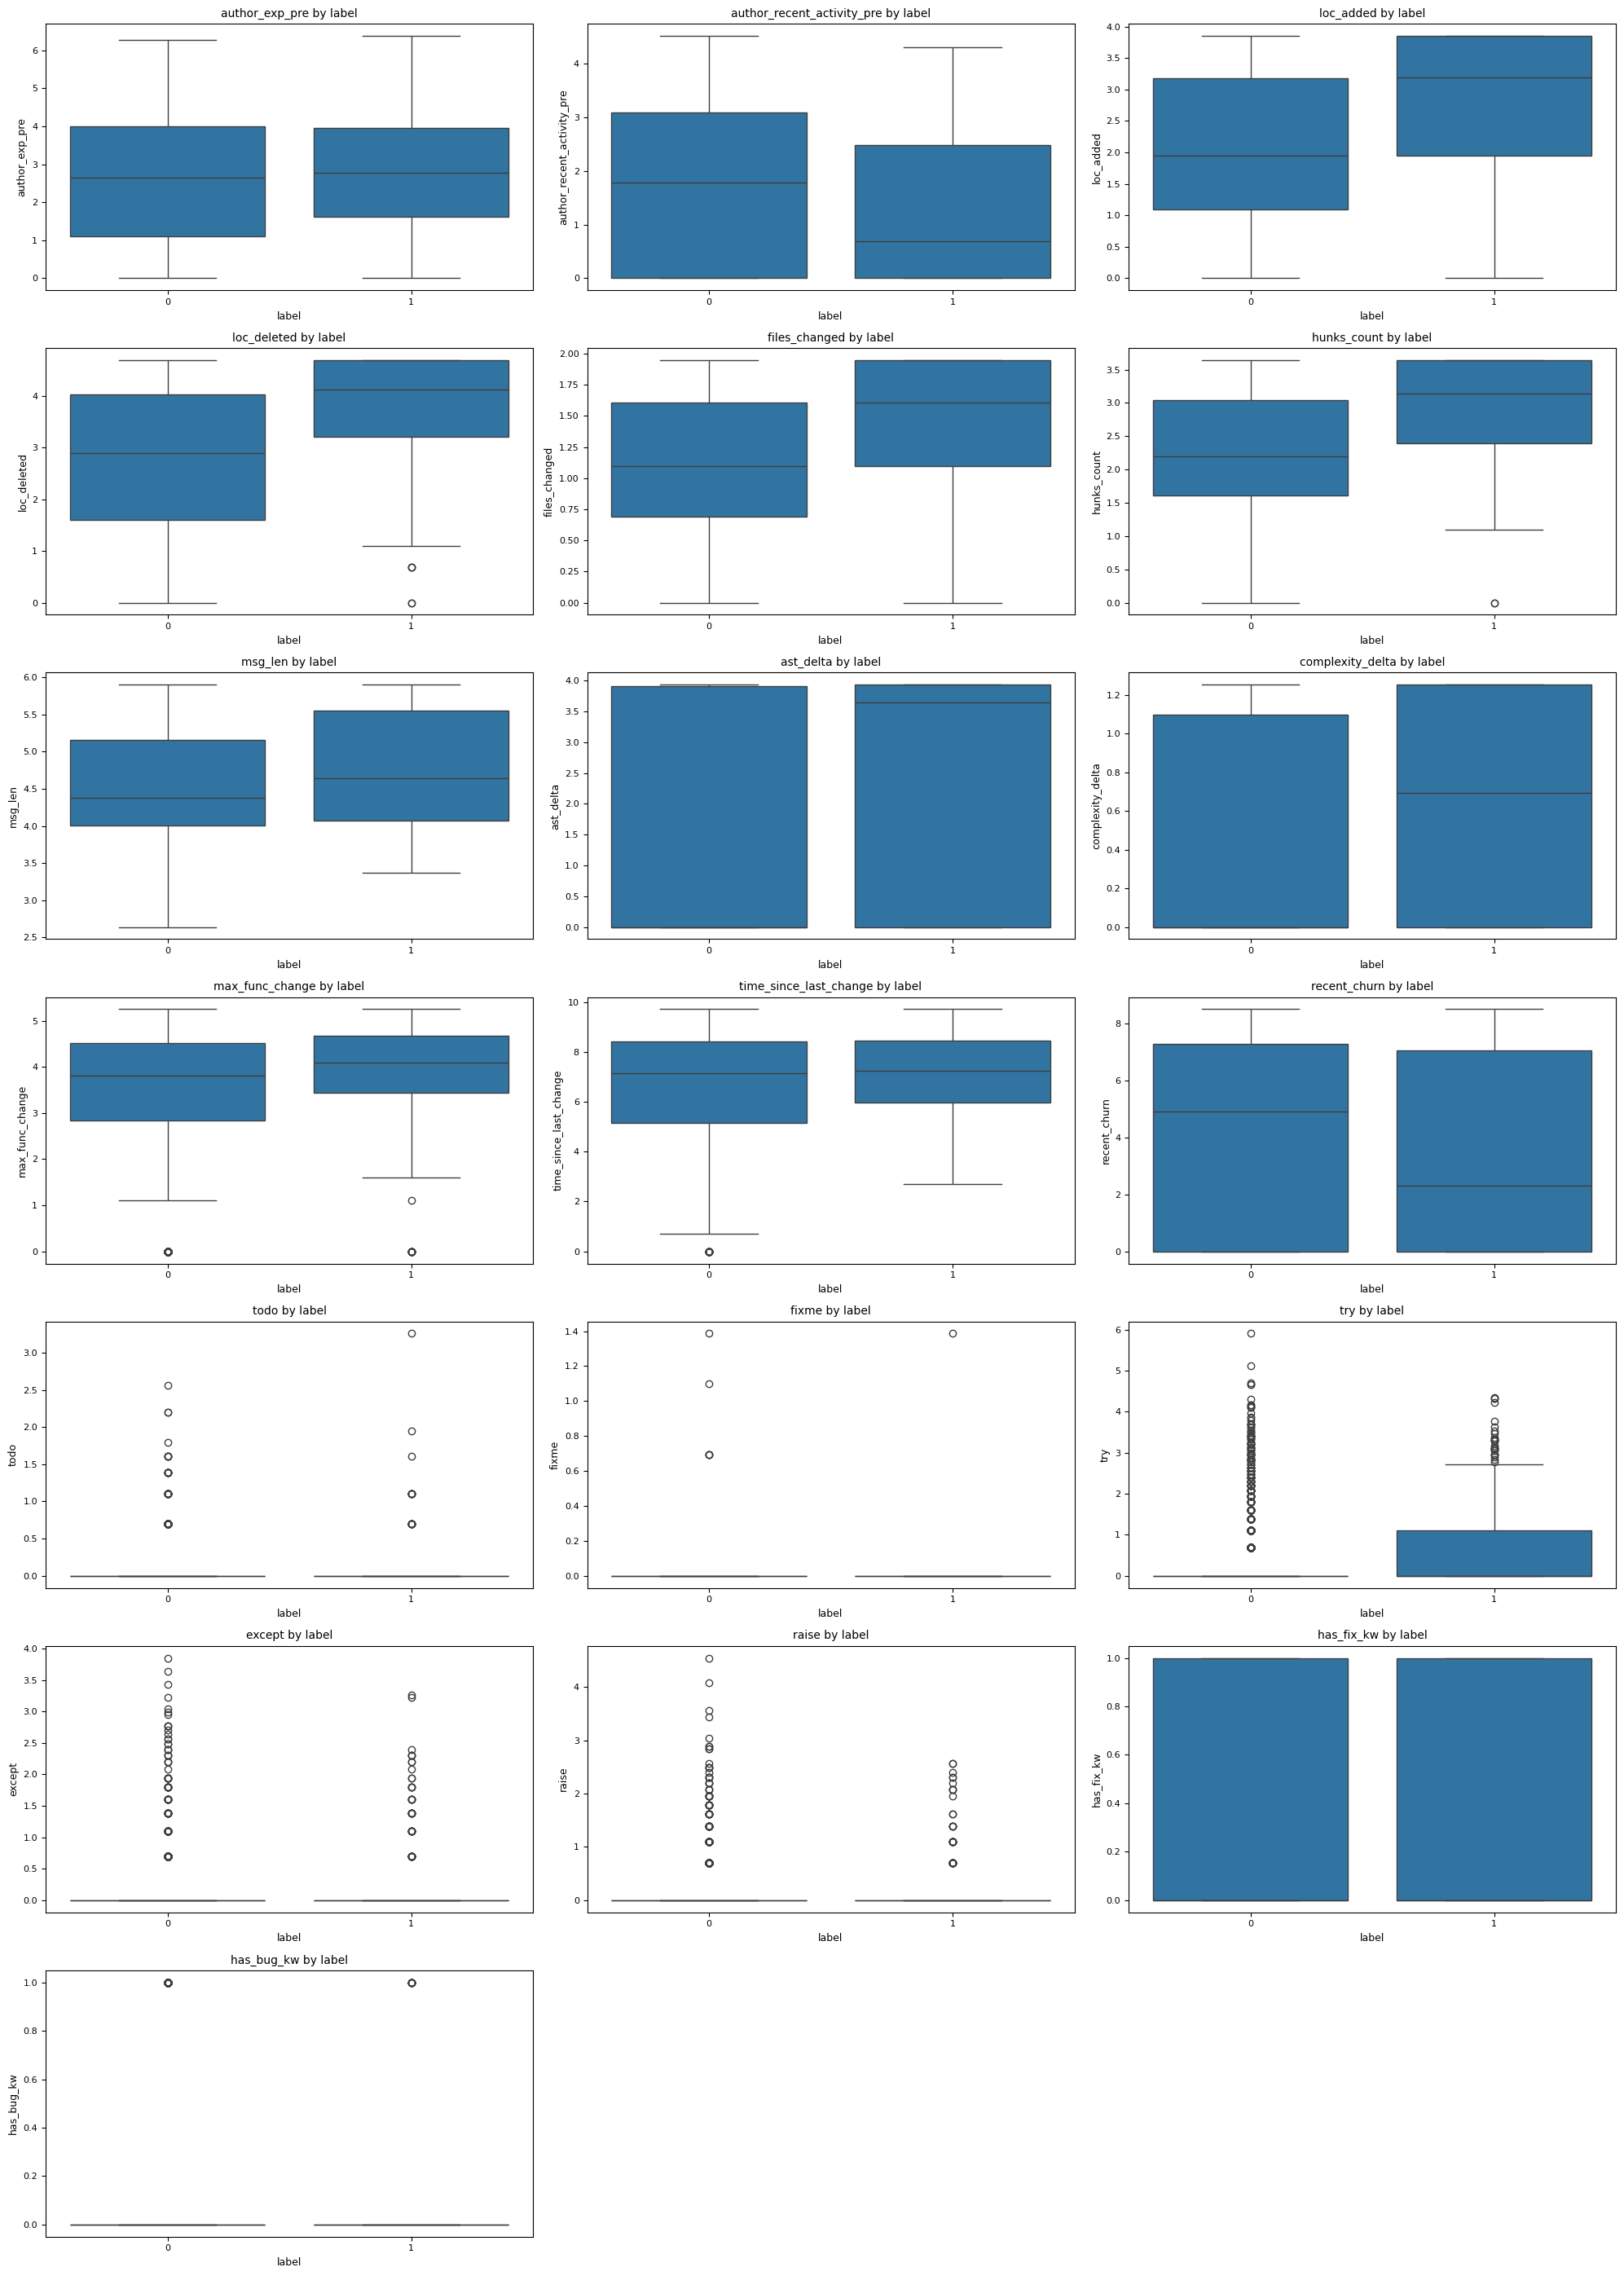

In [80]:
plot_feature_relationships_with_label(df=df, cols=feature_ctgs.numeric_cols, logger=logger)

### 4.2.14 Keyword Features (todo, fixme, try/except/raise)

In [81]:
display_func(plot_keyword_distributions)

def plot_keyword_distributions(
    df: pd.DataFrame, logger: MyLogger, features=LINE_TOKEN_FEATURES
):
    logger.log_check(
        "Checking Keyword Count Distributions... (median, IQR, min, max, zero_ratio)"
    )

    plt.figure(figsize=(15, 5))
    df[features].hist(bins=50, figsize=(15, 5))
    plt.suptitle("Keyword Counts")
    plt.show()

    for feature in features:
        series = df[feature].dropna()
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        median = series.median()
        min_val, max_val = series.min(), series.max()
        zero_ratio = (series == 0).mean()

        logger.log_result(
            f"{feature} | median={median:.2f}, IQR={IQR:.2f}, min={min_val}, max={max_val}, zero_ratio={zero_ratio:.2%}"
        )

[EDA CHECK] Checking Keyword Count Distributions... (median, IQR, min, max, zero_ratio)


<Figure size 1500x500 with 0 Axes>

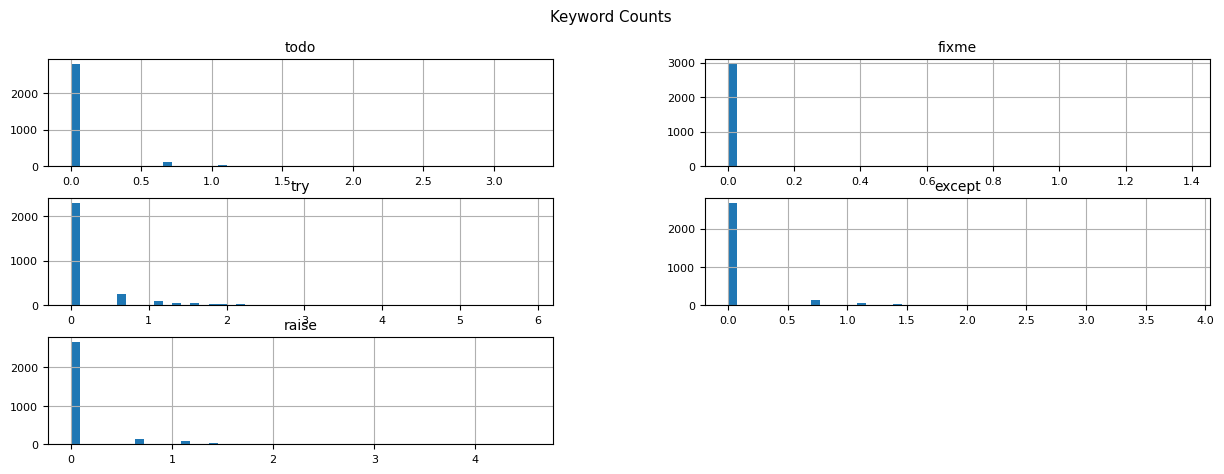

[EDA RESULT] todo | median=0.00, IQR=0.00, min=0.0, max=3.258096538021482, zero_ratio=94.22%
[EDA RESULT] fixme | median=0.00, IQR=0.00, min=0.0, max=1.3862943611198906, zero_ratio=99.76%
[EDA RESULT] try | median=0.00, IQR=0.00, min=0.0, max=5.902633333401366, zero_ratio=77.13%
[EDA RESULT] except | median=0.00, IQR=0.00, min=0.0, max=3.8501476017100584, zero_ratio=89.95%
[EDA RESULT] raise | median=0.00, IQR=0.00, min=0.0, max=4.543294782270004, zero_ratio=89.68%


In [82]:
plot_keyword_distributions(df=df, logger=logger) 


### 4.2.15 Pairwise Relationships
 
Due to high cardinality, use only selected features

In [83]:
display_func(plot_pairwise_relationship)

def plot_pairwise_relationship(
    df: pd.DataFrame,
    feature_ctgs: NumFeatureSets,
    logger: MyLogger,
    top_features: int = 5,
    experiment_dir: Path = None,
):
    # TOP_FEATURES = 5

    # Compute correlations with label
    corr_with_label = (
        df[feature_ctgs.all_numeric_cols() + ["label"]].corr()["label"].drop("label")
    )  # exclude label itself

    # Take top N correlated features
    selected_features = (
        corr_with_label.abs()
        .sort_values(ascending=False)
        .head(top_features)
        .index.to_list()
    )

    # Add label back for hue
    selected_features.append("label")

    # print(selected_features)

    # # selected_features = ['loc_added', 'loc_deleted', 'hunks_count', 'max_func_change', 'label']
    # sns.pairplot(df[selected_features], hue='label', corner=True)
    # plt.suptitle("Pairplot of Selected Features", y=1.02)
    # plt.show()

    # selected_features
    logger.log_check(
        "Checking Selected Feature Distributions and Correlations... (median, IQR, min, max, overlap)"
    )

    # Exclude label for stats
    features_only = selected_features[:-1]

    # Log per-feature stats + overlap coefficient
    for feature in features_only:
        series0 = df[df["label"] == 0][feature].dropna()
        series1 = df[df["label"] == 1][feature].dropna()

        # Basic stats on full feature
        median = df[feature].median()
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        min_val, max_val = df[feature].min(), df[feature].max()

        # Overlap between label groups
        bins = np.histogram_bin_edges(df[feature], bins="auto")
        hist0, _ = np.histogram(series0, bins=bins, density=True)
        hist1, _ = np.histogram(series1, bins=bins, density=True)
        overlap = np.sum(np.minimum(hist0, hist1)) * np.diff(bins)[0]

        logger.log_result(
            f"{feature} | median={median:.2f}, IQR={IQR:.2f}, min={min_val:.2f}, max={max_val:.2f}, overlap={overlap:.2f}"
        )

    # Log pairwise correlations among selected features (excluding label)
    for i, feat1 in enumerate(features_only):
        for feat2 in features_only[i + 1 :]:
            corr_val = df[[feat1, feat2]].corr().iloc[0, 1]
            logger.log_result(f"Correlation {feat1} & {feat2}: {corr_val:.2f}")

    df_sample = df[selected_features].sample(min(len(df), 5000), random_state=42)

    # Pairplot for visualization
    # sns.pairplot(df[selected_features], hue="label", corner=True)
    # In your pairplot call, use plot_kws to rasterize
    sns.pairplot(
        df_sample[selected_features],
        hue="label",
        corner=True,
        plot_kws={
            "rasterized": True,  # This renders the dots as a bitmap
            "alpha": 0.4,
            "s": 5,
            "edgecolor": None,
        },
    )
    plt.suptitle("Pairplot of Selected Features", y=1.02)

    if experiment_dir:
        experiment_dir.mkdir(parents=True, exist_ok=True)
        # save_path = experiment_dir / f"pairwise_relationships.pdf"
        # plt.savefig(save_path, bbox_inches="tight", dpi=300)

        save_as_pdf(experiment_dir / f"pairwise_relationships.pdf")
        save_as_png(experiment_dir / f"pairwise_relationships.png")
    else:
        plt.show()

[EDA CHECK] Checking Selected Feature Distributions and Correlations... (median, IQR, min, max, overlap)
[EDA RESULT] hunks_count | median=2.40, IQR=1.53, min=0.00, max=3.64, overlap=0.65
[EDA RESULT] loc_deleted | median=3.04, IQR=2.38, min=0.00, max=4.69, overlap=0.68
[EDA RESULT] files_changed | median=1.10, IQR=1.10, min=0.00, max=1.95, overlap=0.70
[EDA RESULT] loc_added | median=2.08, IQR=2.23, min=0.00, max=3.85, overlap=0.72
[EDA RESULT] complexity_delta | median=0.00, IQR=1.10, min=0.00, max=1.25, overlap=0.78
[EDA RESULT] Correlation hunks_count & loc_deleted: 0.78
[EDA RESULT] Correlation hunks_count & files_changed: 0.85
[EDA RESULT] Correlation hunks_count & loc_added: 0.75
[EDA RESULT] Correlation hunks_count & complexity_delta: 0.45
[EDA RESULT] Correlation loc_deleted & files_changed: 0.65
[EDA RESULT] Correlation loc_deleted & loc_added: 0.58
[EDA RESULT] Correlation loc_deleted & complexity_delta: 0.45
[EDA RESULT] Correlation files_changed & loc_added: 0.62
[EDA RESU

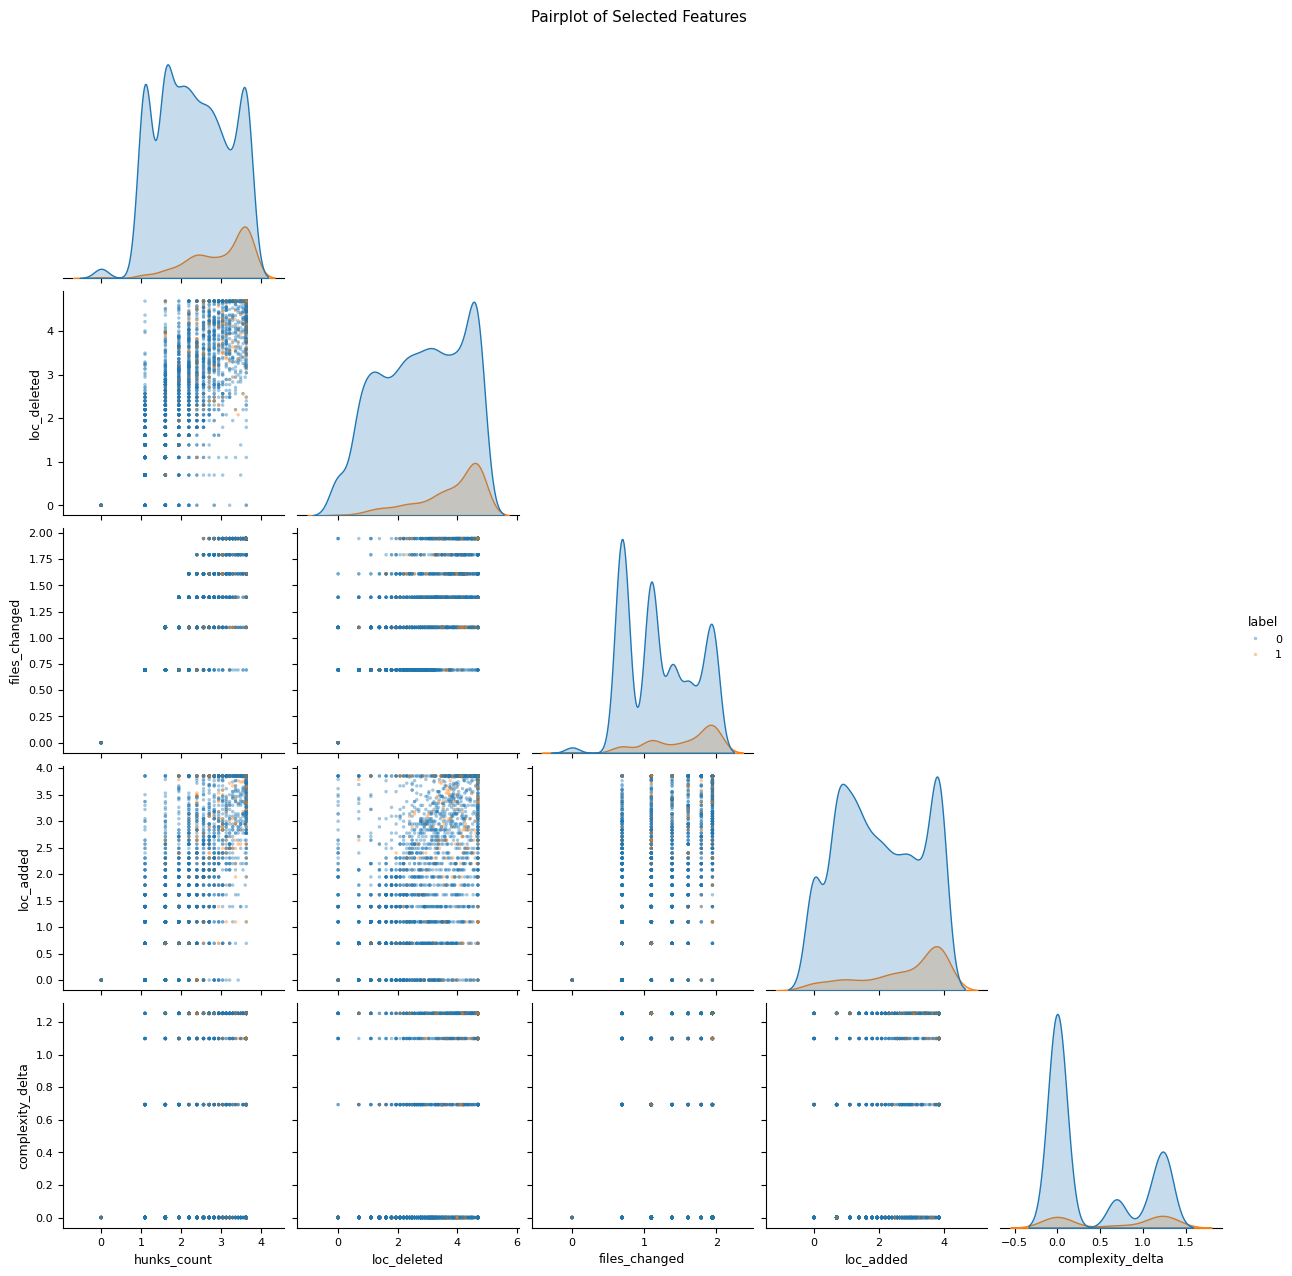

In [84]:
plot_pairwise_relationship(df=df, feature_ctgs=feature_ctgs, logger=logger)

### 4.2.16 Optional: t-SNE / PCA on Embeddings

Reduce embedding dimensions to 2D to visualize clustering by label

In [85]:
display_func(plot_2D_embedding_separability)

def plot_2D_embedding_separability(
    df: pd.DataFrame,
    logger: MyLogger,
    embeddings=EMBEDDINGS,
    sample_size: int = 2000,
    experiment_dir: Path = None,
):
    # sample_size = 2000  # safe for memory
    results_df = pd.DataFrame({
        "embedding": [],
        "inter_label_dist": [],
        "intra_dist_label0": [],
        "intra_dist_label1": [],
    })


    for emb_name in embeddings:
        logger.log_check(f"PCA of {emb_name}")

        # Stack embeddings into 2D array
        emb_matrix = np.vstack(df[emb_name].values)

        # PCA to 2D
        # pca = PCA(n_components=2)
        # emb_2d = pca.fit_transform(emb_matrix)
        pca = PCA(n_components=2)
        # Force the result to be a NumPy array immediately
        emb_2d = np.array(pca.fit_transform(emb_matrix))

        # Explained variance
        var_explained = pca.explained_variance_ratio_
        logger.log_result(
            f"{emb_name} - Explained variance by PC1: {var_explained[0]:.2%}, PC2: {var_explained[1]:.2%}"
        )

        # 1. Split by labels (Ensure these are numpy arrays)
        labels = df["label"].values
        points_label0 = emb_2d[labels == 0]
        points_label1 = emb_2d[labels == 1]

        # 2. Fixed Sampling: Use iloc if it's a DF, or index directly if it's an array
        # To be safe, we force points_label0 to be a numpy array if it isn't already
        if hasattr(points_label0, "values"):
            points_label0 = points_label0.values
        if hasattr(points_label1, "values"):
            points_label1 = points_label1.values

        idx0 = np.random.choice(
            points_label0.shape[0],
            min(sample_size, points_label0.shape[0]),
            replace=False,
        )
        idx1 = np.random.choice(
            points_label1.shape[0],
            min(sample_size, points_label1.shape[0]),
            replace=False,
        )

        points_label0_sample = points_label0[idx0]
        points_label1_sample = points_label1[idx1]

        # Distances
        inter_label_dist = pairwise_distances(
            points_label0_sample, points_label1_sample
        ).mean()
        intra_dist_label0 = pairwise_distances(points_label0_sample).mean()
        intra_dist_label1 = pairwise_distances(points_label1_sample).mean()

        logger.log_result(
            f"{emb_name} - Mean distance between label 0 and 1 in PCA 2D space: {inter_label_dist:.3f}"
        )
        logger.log_result(
            f"{emb_name} - Mean intra-label distances: label 0: {intra_dist_label0:.3f}, label 1: {intra_dist_label1:.3f}"
        )

    

        # results_df = pd.DataFrame({
        #     "inter_label_dist": [f"{inter_label_dist:.3f}"],
        #     "intra_dist_label0": [f"{intra_dist_label0:.3f}"],
        #     "intra_dist_label1": [f"{intra_dist_label1:.3f}"],
        # })
        results_df.loc[len(results_df)] = {
            "embedding": emb_name,
            "inter_label_dist": inter_label_dist,
            "intra_dist_label0": intra_dist_label0,
            "intra_dist_label1": intra_dist_label1,
        }

        if experiment_dir:
            experiment_dir.mkdir(parents=True, exist_ok=True)
            save_df_as_md(df=results_df.round(3), path=experiment_dir / f"{emb_name}_stats.md")

        # Plot
        plt.figure(figsize=(10, 7))
        plt.scatter(
            emb_2d[:, 0], emb_2d[:, 1], c=df["label"], cmap="coolwarm", alpha=0.5
        )
        plt.title(f"PCA of {emb_name} Colored by Label")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        # plt.show()
        if experiment_dir:
            experiment_dir.mkdir(parents=True, exist_ok=True)
            save_path = experiment_dir / f"2D_{emb_name}_embedding_separability.pdf"
            plt.savefig(save_path, bbox_inches="tight", dpi=300)
        else:
            plt.show()

    
    return results_df

[EDA CHECK] PCA of code_embed
[EDA RESULT] code_embed - Explained variance by PC1: 30.07%, PC2: 18.90%
[EDA RESULT] code_embed - Mean distance between label 0 and 1 in PCA 2D space: 2.041
[EDA RESULT] code_embed - Mean intra-label distances: label 0: 2.062, label 1: 2.007


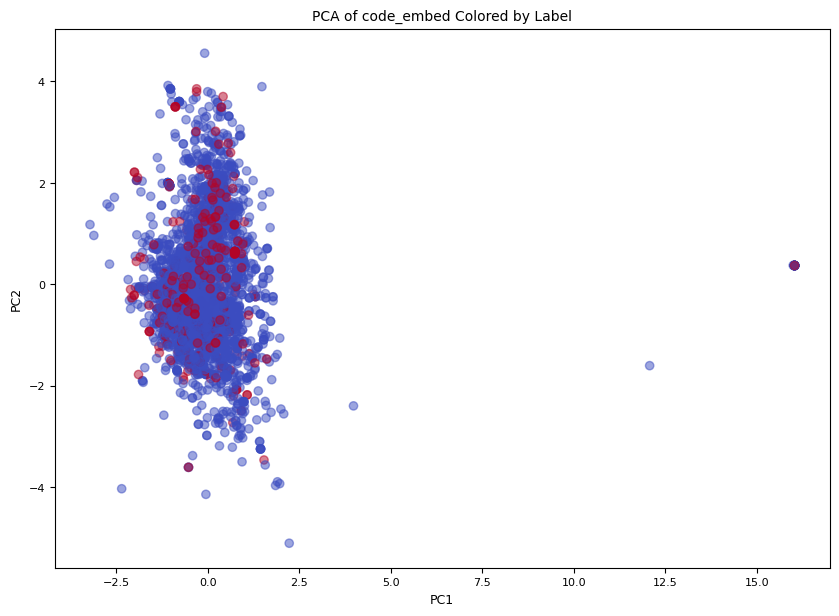

[EDA CHECK] PCA of msg_embed
[EDA RESULT] msg_embed - Explained variance by PC1: 21.79%, PC2: 15.69%
[EDA RESULT] msg_embed - Mean distance between label 0 and 1 in PCA 2D space: 2.599
[EDA RESULT] msg_embed - Mean intra-label distances: label 0: 2.370, label 1: 2.747


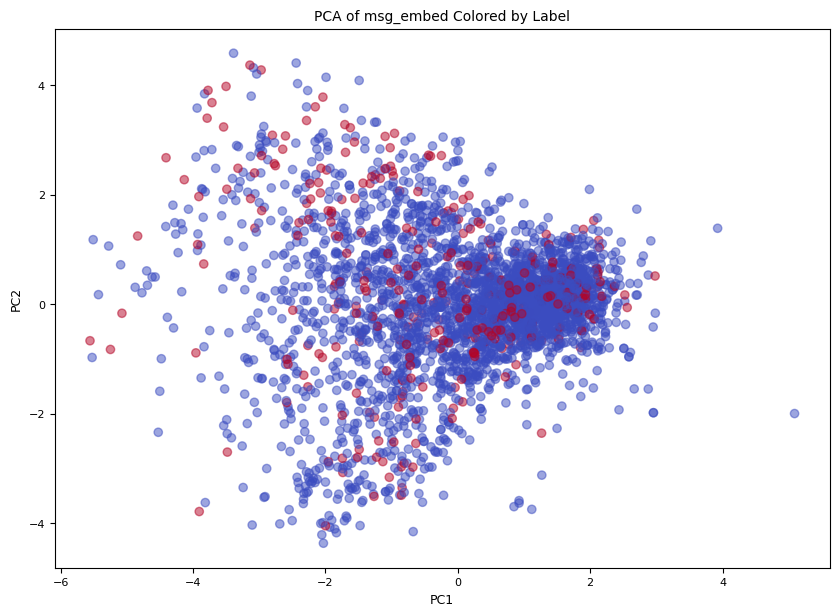

,embedding,inter_label_dist,intra_dist_label0,intra_dist_label1
0,code_embed,2.040749,2.062282,2.007138
1,msg_embed,2.598565,2.369522,2.746516


In [86]:
plot_2D_embedding_separability(df=df, logger=logger, sample_size=2000)

#### Interpretation:

- If points of different labels cluster separately → the embeddings capture some discriminative information for predicting bugs.
- If points overlap heavily → embeddings might not strongly differentiate buggy vs. non-buggy commits.
- You can also get an idea of outliers or general spread of the embeddings.

This visualization helps you explore how informative the embeddings are for your target labels in 2D space.